## 准备数据

In [40]:
# import os
# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers, optimizers, datasets

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'}

# def mnist_dataset():
#     (x, y), (x_test, y_test) = datasets.mnist.load_data()
#     #normalize
#     x = x/255.0
#     x_test = x_test/255.0
    
#     return (x, y), (x_test, y_test)
import numpy as np
import matplotlib.pyplot as plt

def generate_data():
    # 生成拟合目标：y = sin(x) + 0.5x
    x = np.linspace(-5, 5, 500).reshape(-1, 1)
    y = np.sin(x) + 0.5 * x
    
    # 划分训练集和测试集
    indices = np.random.permutation(len(x))
    train_idx, test_idx = indices[:400], indices[400:]
    return (x[train_idx], y[train_idx]), (x[test_idx], y[test_idx])

# 获取数据
(x_train, y_train), (x_test, y_test) = generate_data()

In [41]:
print(list(zip([1, 2, 3, 4], ['a', 'b', 'c', 'd'])))

[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]


In [42]:
import numpy as np

class Matmul:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x, W):
        h = np.matmul(x, W)
        self.mem={'x': x, 'W':W}
        return h
    
    def backward(self, grad_y):
        x = self.mem['x']
        W = self.mem['W']
        grad_x = np.matmul(grad_y, W.T)
        grad_W = np.matmul(x.T, grad_y)
        return grad_x, grad_W

class Relu:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x):
        self.mem['x']=x
        return np.where(x > 0, x, np.zeros_like(x))
    
    def backward(self, grad_y):
        x = self.mem['x']
        grad_x = grad_y * (x > 0)
        return grad_x

## 建立模型

In [ ]:
# class myModel:
#     def __init__(self):
#         ####################
#         '''声明模型对应的参数'''
#         ####################
#     def __call__(self, x):
#         ####################
#         '''实现模型函数体，返回未归一化的logits'''
#         ####################
#         return logits
        
# model = myModel()

# optimizer = optimizers.Adam()
class myModel:
    def __init__(self):
        # 增加隐藏层神经元到 256
        hidden_dim = 256
        
        # 使用 He 初始化改善非线性拟合
        self.W1 = np.random.normal(size=[2, hidden_dim], scale=np.sqrt(2/2))
        self.W2 = np.random.normal(size=[hidden_dim, 1], scale=np.sqrt(2/hidden_dim))
        
        self.mul_h1 = Matmul()
        self.relu = Relu()
        self.mul_h2 = Matmul()
        
    def forward(self, x):
        # 确保输入 x 包含偏置项列
        bias = np.ones(shape=[x.shape[0], 1])
        x_full = np.concatenate([x, bias], axis=1)
        
        self.h1 = self.mul_h1.forward(x_full, self.W1)
        self.h1_relu = self.relu.forward(self.h1)
        self.h2 = self.mul_h2.forward(self.h1_relu, self.W2)
        return self.h2 
            
    def backward(self, label):
        # MSE 梯度：(pred - target) / batch_size
        grad_loss = (self.h2 - label) / self.h2.shape[0]
        
        self.h2_grad, self.W2_grad = self.mul_h2.backward(grad_loss)
        self.h1_relu_grad = self.relu.backward(self.h2_grad)
        _, self.W1_grad = self.mul_h1.backward(self.h1_relu_grad)
        
model = myModel()

## 计算 loss

In [ ]:
# @tf.function
# def compute_loss(logits, labels):
#     return tf.reduce_mean(
#         tf.nn.sparse_softmax_cross_entropy_with_logits(
#             logits=logits, labels=labels))

# @tf.function
# def compute_accuracy(logits, labels):
#     predictions = tf.argmax(logits, axis=1)
#     return tf.reduce_mean(tf.cast(tf.equal(predictions, labels), tf.float32))

# @tf.function
# def train_one_step(model, optimizer, x, y):
#     with tf.GradientTape() as tape:
#         logits = model(x)
#         loss = compute_loss(logits, y)

#     # compute gradient
#     trainable_vars = [model.W1, model.W2, model.b1, model.b2]
#     grads = tape.gradient(loss, trainable_vars)
#     for g, v in zip(grads, trainable_vars):
#         v.assign_sub(0.01*g)

#     accuracy = compute_accuracy(logits, y)

#     # loss and accuracy is scalar tensor
#     return loss, accuracy

# @tf.function
# def test(model, x, y):
#     logits = model(x)
#     loss = compute_loss(logits, y)
#     accuracy = compute_accuracy(logits, y)
#     return loss, accuracy
def compute_loss(pred, labels):
    # 均方误差损失
    return np.mean(0.5 * (pred - labels)**2)

def train_one_step(model, x, y, lr=0.01):
    pred = model.forward(x)
    model.backward(y)
    # 手动更新权重 
    model.W1 -= lr * model.W1_grad
    model.W2 -= lr * model.W2_grad
    return compute_loss(pred, y)

## 实际训练

Epoch 0: Loss = 1.554371
Epoch 1000: Loss = 0.016844
Epoch 2000: Loss = 0.008301
Epoch 3000: Loss = 0.005600
Epoch 4000: Loss = 0.004130


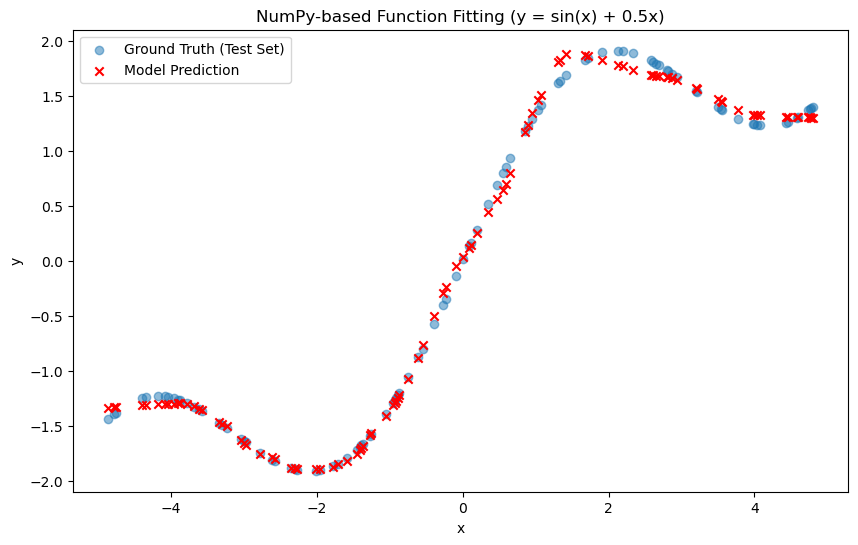

In [ ]:
# train_data, test_data = mnist_dataset()
# for epoch in range(50):
#     loss, accuracy = train_one_step(model, optimizer, 
#                                     tf.constant(train_data[0], dtype=tf.float32), 
#                                     tf.constant(train_data[1], dtype=tf.int64))
#     print('epoch', epoch, ': loss', loss.numpy(), '; accuracy', accuracy.numpy())
# loss, accuracy = test(model, 
#                       tf.constant(test_data[0], dtype=tf.float32), 
#                       tf.constant(test_data[1], dtype=tf.int64))

# print('test loss', loss.numpy(), '; accuracy', accuracy.numpy())
# 增加训练轮数
for epoch in range(5000):
    loss = train_one_step(model, x_train, y_train, lr=0.005) 
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}: Loss = {loss:.6f}')

# 可视化
y_pred = model.forward(x_test)
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, label='Ground Truth (Test Set)', alpha=0.5)
plt.scatter(x_test, y_pred, label='Model Prediction', marker='x', color='red')
plt.title("NumPy-based Function Fitting (y = sin(x) + 0.5x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()